In [1]:
import torch
from typing import Tuple, Optional, Union
import numpy as np

@torch.no_grad()
def generate_block_masks_ragged(
    B: int,
    N: int,
    dim: int = 2,
    lengths: Optional[torch.Tensor] = None,   # e.g. 2**torch.arange(5)
    t: Union[float, torch.Tensor] = 0.9,      # scalar or [B] target fraction
    round_from: int = 5,
    *,
    device: Optional[torch.device] = None,
    dtype: torch.dtype = torch.float32,
) -> Tuple[torch.Tensor, torch.Tensor]:
    """
    Vectorized generator for union-of-blocks masks with per-sample, ragged block counts.

    This creates a binary mask per batch item by placing axis-aligned hypercubes
    (“blocks”) of side lengths provided in `lengths` onto an N^dim canvas and taking
    the union. For each sample and length ℓ, we (1) compute the maximum number of
    blocks allowed to approximately match a target coverage t, (2) split those
    counts across lengths via normalized random weights, and (3) draw start
    positions uniformly (with the same border-truncation as the reference code).
    Overlaps are allowed and reduce realized coverage.

    Shape & semantics
    -----------------
    - Output `masks`: `[B, *([N]*dim)]` with values in {0., 1.}.
      * dim = 1 → `[B, N]`
      * dim = 2 → `[B, N, N]`
      * dim = 3 → `[B, N, N, N]`
    - Output `actual_t`: `[B]` empirical masked fraction after overlaps.

    Args:
        B: Batch size.
        N: Spatial size per axis (canvas is N^dim).
        dim: 1, 2, or 3 (number of spatial dimensions).
        lengths: 1D tensor of positive block side lengths (e.g., `2**torch.arange(5)`).
                 If None, defaults to powers of two `[1,2,4,8,16]` on `device`.
        t: Target masked fraction. Either a float (applied to all B) or a length-B tensor
           with per-sample targets in [0,1]. This is *approximate* (overlaps reduce it).
        round_from: int, lengths with indices ≥ round_from are rounded to nearest integer, 
            heuristically prevents large blocks to appear too often.
        device: Torch device for all allocations; defaults to CUDA if available.
        dtype: Floating dtype of the returned mask (0/1 stored as floats).

    Returns:
        masks: Tensor of shape `[B, *([N]*dim)]`, binary in {0., 1.} (stored in `dtype`).
        actual_t: Tensor `[B]`, realized masked fraction (masks.mean over spatial dims).

    Algorithmic details (matches the reference loop)
    ------------------------------------------------
    - For each length ℓ in `lengths`:
        area(ℓ) = ℓ**dim
        max_elem[b, ℓ] = ceil(t[b] * N**dim / area(ℓ))
      We then draw bs[b, ℓ] ~ U(0,1), normalize across ℓ, and set
        coeff[b, ℓ] = ceil( bs_norm[b, ℓ] * max_elem[b, ℓ] )
      This yields *ragged* per-length counts per sample (`coeff` varies with b and ℓ).
    - Start positions are drawn from `[1-ℓ, N)` per axis, then clamped to [0, N-1],
      reproducing the “truncate at border” behavior of slicing in the original code.
    - Blocks are written by vectorized index updates; overlaps simply keep 1.

    Determinism:
        The function is stochastic (uses `torch.randint` / `torch.rand`). For reproducible
        masks, seed the appropriate RNGs (e.g., `torch.manual_seed(...)` and for CUDA
        `torch.cuda.manual_seed_all(...)`) before calling.

    Complexity:
        Time/space scale with sum over lengths of (max_per_length coeff) and block volume.
        If extremely many tiny blocks are requested, consider clamping `coeff` to a cap.

    Caveats:
        - `actual_t` ≤ target `t` typically, because of overlaps.
        - Very large `coeff` with tiny `lengths` can be memory heavy; you may cap counts
          or split `lengths` into groups if needed.

    Example:
        >>> N, dim = 28, 2
        >>> B = 8
        >>> lengths = 2**torch.arange(5)  # [1,2,4,8,16]
        >>> masks, actual_t = generate_block_masks_ragged(
        ...     B=B, N=N, dim=dim, lengths=lengths, t=0.9, device="cuda"
        ... )
        >>> masks.shape
        torch.Size([8, 28, 28])
        >>> actual_t  # realized coverage per sample
        tensor([...], device='cuda:0')

        """
    assert dim in (1, 2, 3)
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if lengths is None:
        lengths = 2**torch.arange(5, device=device)
    else:
        lengths = lengths.to(device)
    Lm = lengths.numel()

    # t as [B]
    if isinstance(t, float) or isinstance(t, int):
        t = torch.full((B,), float(t), device=device)
    else:
        t = t.to(device)
        assert t.shape == (B,), f"t must be scalar or shape [B], got {t.shape}"

    Npow = N ** dim
    area = lengths ** dim  # [Lm]

    # max_elem[b, i] = ceil(t[b] * N^dim / area[i])
    max_elem = torch.ceil(t.view(B, 1) * (Npow / area.view(1, Lm))).to(torch.long)  # [B, Lm]
    # bs ~ U(0,1) per (b, i), normalized across i
    bs = torch.rand(B, Lm, device=device)
    bs_norm = bs / bs.sum(dim=-1, keepdim=True).clamp_min(1e-12)

    # coeff = torch.round(bs_norm * max_elem).to(torch.long)  # [B, Lm]
    coeff = bs_norm * max_elem
    coeff[:,:round_from] = coeff[:, :round_from].ceil()
    coeff[:,round_from:] = coeff[:, round_from:].round()

    # Canvas
    spatial_shape = (N,) * dim
    masks = torch.zeros((B, *spatial_shape), device=device, dtype=dtype)

    # Helper: write blocks for one length (vectorized across B, ragged across samples)
    def write_blocks_for_length(length_i: int, coeff_i: torch.Tensor):
        """
        length_i: python int
        coeff_i: [B] long, number of blocks to place for each sample at this length
        """
        Mi = int(coeff_i.max().item())  # pad-to length-specific max
        if Mi == 0:
            return

        # Starts: [B, Mi, dim]; low = 1-length, high = N, then clamp to [0, N-1] like your code
        low = 1 - length_i
        starts = torch.randint(low=low, high=N, size=(B, Mi, dim), device=device)
        starts.clamp_min_(0)

        # Active mask: keep first coeff_i for each b
        ar = torch.arange(Mi, device=device).unsqueeze(0)  # [1, Mi]
        active = (ar < coeff_i.unsqueeze(1))               # [B, Mi]

        # Offsets for block side
        offs = torch.arange(length_i, device=device)

        if dim == 1:
            # positions: [B, Mi, length_i]
            x = (starts[..., 0].unsqueeze(-1) + offs).clamp_max(N - 1)
            valid = active.unsqueeze(-1).expand_as(x)      # [B, Mi, length_i]

            idx = torch.nonzero(valid, as_tuple=False)     # [Q, 3] -> (b, mi, u)
            b = idx[:, 0]
            xv = x[b, idx[:, 1], idx[:, 2]]

            masks[b, xv] = 1.0

        elif dim == 2:
            # x,y: [B, Mi, length_i]
            x = (starts[..., 0].unsqueeze(-1) + offs).clamp_max(N - 1)
            y = (starts[..., 1].unsqueeze(-1) + offs).clamp_max(N - 1)
            # grids: [B, Mi, length_i, length_i]
            xg = x.unsqueeze(-1).expand(-1, -1, -1, length_i)
            yg = y.unsqueeze(-2).expand(-1, -1, length_i, -1)

            valid = active.unsqueeze(-1).unsqueeze(-1).expand_as(xg)

            # Flattened linear indices, then write on flattened canvas
            idx = torch.nonzero(valid, as_tuple=False)     # [Q, 4] -> (b, mi, u, v)
            b = idx[:, 0]
            xv = xg[idx[:, 0], idx[:, 1], idx[:, 2], idx[:, 3]]
            yv = yg[idx[:, 0], idx[:, 1], idx[:, 2], idx[:, 3]]
            lin = (xv * N + yv)                            # [Q]

            flat = masks.view(B, -1)                       # [B, N*N]
            flat[b, lin] = 1.0

        else:  # dim == 3
            x = (starts[..., 0].unsqueeze(-1) + offs).clamp_max(N - 1)  # [B, Mi, l]
            y = (starts[..., 1].unsqueeze(-1) + offs).clamp_max(N - 1)
            z = (starts[..., 2].unsqueeze(-1) + offs).clamp_max(N - 1)

            xg = x.unsqueeze(-1).unsqueeze(-1).expand(-1, -1, -1, length_i, length_i)
            yg = y.unsqueeze(-2).unsqueeze(-1).expand(-1, -1, length_i, -1, length_i)
            zg = z.unsqueeze(-2).unsqueeze(-2).expand(-1, -1, length_i, length_i, -1)

            valid = active.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1).expand_as(xg)

            idx = torch.nonzero(valid, as_tuple=False)     # [Q, 5] -> (b, mi, u, v, w)
            b = idx[:, 0]
            xv = xg[idx[:, 0], idx[:, 1], idx[:, 2], idx[:, 3], idx[:, 4]]
            yv = yg[idx[:, 0], idx[:, 1], idx[:, 2], idx[:, 3], idx[:, 4]]
            zv = zg[idx[:, 0], idx[:, 1], idx[:, 2], idx[:, 3], idx[:, 4]]

            lin = (xv * (N * N) + yv * N + zv)

            flat = masks.view(B, -1)                       # [B, N^3]
            flat[b, lin] = 1.0

    # Loop only over distinct lengths (tiny), everything else is vectorized
    for i in range(Lm):
        write_blocks_for_length(int(lengths[i].item()), coeff[:, i])

    # realized fraction per sample
    actual_t = masks.view(B, -1).mean(dim=-1)  # [B]
    return masks.bool(), actual_t

(array([ 1.,  2.,  6.,  5.,  9., 12.,  9., 11., 14.,  3., 15., 13.,  9.,
         2.,  3.,  4.,  4.,  0.,  3.,  3.]),
 array([0.21875   , 0.2453125 , 0.27187499, 0.29843751, 0.32499999,
        0.3515625 , 0.37812501, 0.40468749, 0.43125001, 0.45781249,
        0.484375  , 0.51093751, 0.53750002, 0.56406248, 0.59062499,
        0.6171875 , 0.64375001, 0.67031252, 0.69687498, 0.72343749,
        0.75      ]),
 <BarContainer object of 20 artists>)

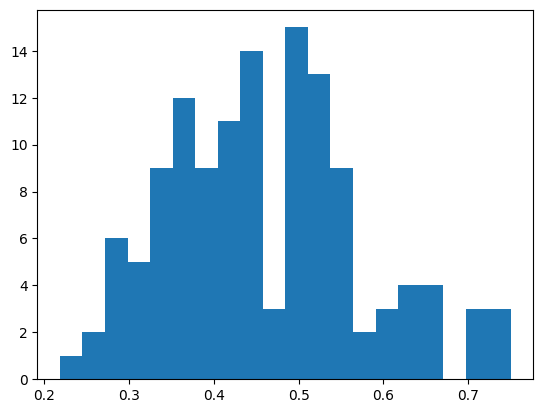

In [18]:
import matplotlib.pyplot as plt
lengths = [4,6,8,16,20]
B = 128
N = 64

dim=1
# check real covered with t covered
masks, actual_t = generate_block_masks_ragged(B=B, N=N, dim=dim, lengths=torch.tensor(lengths), t=0.4, round_from=3)


plt.hist(actual_t.cpu().numpy(), bins=20)
